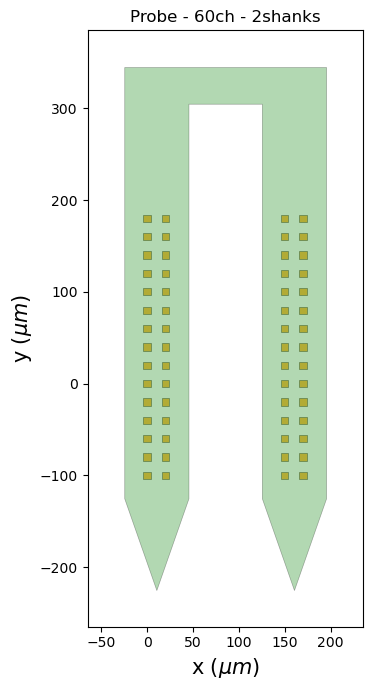

In [1]:
import matplotlib.pyplot as plt
from probeinterface import generate_multi_shank
from probeinterface.plotting import plot_probe

# Simulate shortened version of probe

multi_shank = generate_multi_shank(
    num_shank=2,
    num_columns=2,
    num_contact_per_column=15,
    ypitch=20,
    contact_shapes='square',
    contact_shape_params={'width': 8, 'height': 8},
)

y_pad = 100  # um

y_contact_top = multi_shank.contact_positions[:, 1].max()

multi_shank.contact_positions[:, 1] -= y_pad

contour = multi_shank.probe_planar_contour
contour[:, 1] -= y_pad

base_mask = contour[:, 1] > (y_contact_top - y_pad)
contour[base_mask, 1] += y_pad

fig, ax = plt.subplots(figsize=(4, 7))
plot_probe(multi_shank, ax=ax)
plt.tight_layout()
plt.show()

## Load data borrowed from the Cullen lab

In [2]:
import numpy as np
import spikeinterface as si

# Config
CONTROL_DATA = '/home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW026_260324_121810'

STIM_DATA = '/home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW026_260324_122125'

NPRW_SORT_CKPT_OUT = '/home/bryan/Documents/workspace/NII_project/folder_KS4'
NPRW_SORT_ANALYZE_CKPT_OUT = '/home/bryan/Documents/workspace/NII_project/my_sorting_analyzer'

rec_nprw_control = si.load(CONTROL_DATA)

## Load IR data

In [ ]:
IR_data_control = '/home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/rates__NRR_RW026_260324_121810__bin20ms_sigma20ms.npz'

ir_si_obj_control = np.load(IR_data_control, allow_pickle=True) 
ir_ms = np.asarray(ir_si_obj_control["ir_ms"], float).ravel()
ir_ms

array([  8246.66666667,  13442.63333333,  18445.56666667,  23682.03333333,
        29441.13333333,  35494.2       ,  40569.26666667,  45421.43333333,
        50640.56666667,  55586.43333333,  59918.63333333,  64437.8       ,
        69371.1       ,  74298.73333333,  79042.53333333,  83471.03333333,
        88525.03333333,  94051.        ,  98184.76666667, 102781.36666667,
       106891.3       , 111348.63333333, 116146.93333333, 116396.46666667,
       121560.53333333, 126040.8       , 131394.66666667])

## Peak detection using thresholding for control

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import spikeinterface as si
from spikeinterface.sortingcomponents.peak_detection import detect_peaks

noise_levels = si.get_noise_levels(rec_nprw_control, method="mad", return_in_uV=False)
peaks = detect_peaks(
    rec_nprw_control,
    method="by_channel_torch",
    method_kwargs=dict(detect_threshold=3, peak_sign="neg", noise_levels=noise_levels),
    job_kwargs=dict(n_jobs=1),
)

def _parse_SI_peaks(peaks, n_channels: int) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times = {i: np.array([], dtype=np.int64)   for i in range(n_channels)}
    peak_amps  = {i: np.array([], dtype=np.float32) for i in range(n_channels)}
    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = ch_idx == i
        peak_times[ii] = peaks["sample_index"][m]
        peak_amps[ii]  = peaks["amplitude"][m]
    return peak_times, peak_amps

nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(peaks, 128)
nprw_peak_ms_control = {k: v / 30000 * 1000.0 for k, v in nprw_peak_samps.items()}


noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks (by_channel_torch) (no parallelization):   0%|          | 0/134 [00:00<?, ?it/s]

## Plotting raw trace with peaks

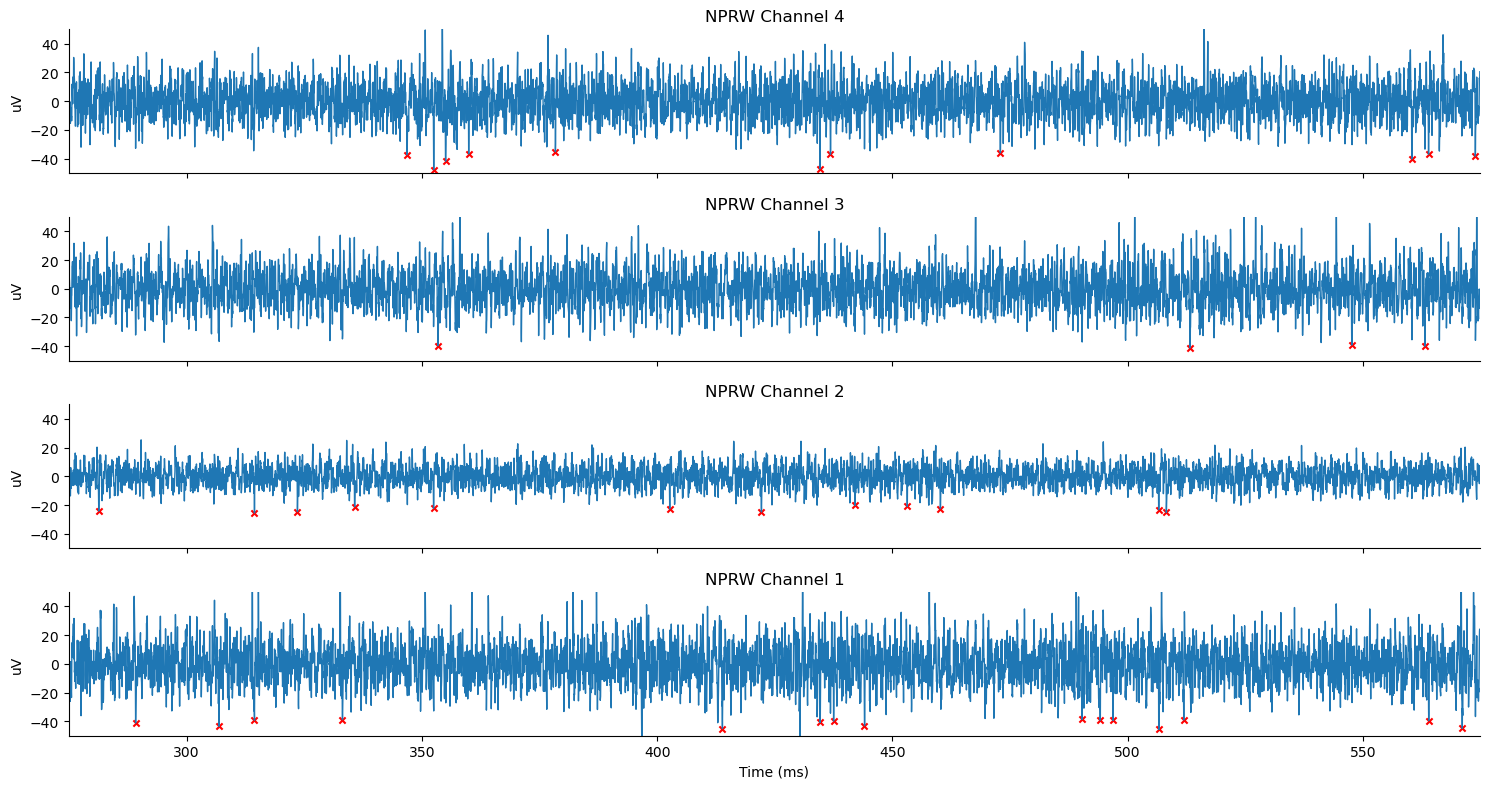

In [5]:
%matplotlib inline

CHANNELS  = [0, 1, 2, 3]
T0_MS     = 8247 / 30
T1_MS     = T0_MS + 300
PLOT_SHIFT = 30  # samples; compensates for threshold-crossing vs trough offset

fs = float(rec_nprw_control.get_sampling_frequency())
i0 = int(T0_MS * fs / 1000.0)
i1 = int(T1_MS * fs / 1000.0)

fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(15, 3 * len(CHANNELS) / 1.5), sharex=True)
if len(CHANNELS) == 1:
    axes = [axes]

for ax, CH in zip(axes, CHANNELS[::-1]):
    ch_id = rec_nprw_control.get_channel_ids()[CH]
    y = rec_nprw_control.get_traces(start_frame=i0, end_frame=i1, channel_ids=[ch_id], return_in_uV=True).squeeze()
    t = np.arange(i0, i1) / fs * 1000.0

    pk_s = np.asarray(nprw_peak_samps.get(CH, nprw_peak_samps.get(np.int64(CH), [])), dtype=np.int64)
    m = (pk_s >= i0) & (pk_s < i1)
    pk_s_w = pk_s[m]
    pk_idx = (pk_s_w - i0).astype(int)
    pk_ms_w = pk_s_w / fs * 1000.0
    pk_y = y[pk_idx + PLOT_SHIFT]

    ax.plot(t, y, lw=1)
    if pk_ms_w.size:
        ax.scatter(pk_ms_w + PLOT_SHIFT / 30, pk_y, s=20, marker="x", color="red")
    ax.set_xlim(T0_MS, T1_MS)
    ax.set_ylim(-50, 50)
    ax.set_ylabel("uV")
    ax.set_title(f"NPRW Channel {CH + 1}")
    ax.spines[["right", "top"]].set_visible(False)

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

## PSTH shows temporal tuning the reach phase

In [6]:
def peri_event_rates_from_peaks_ms(
    peaks_ms: dict[int, np.ndarray],
    event_times_ms: np.ndarray,
    win_ms: tuple[float, float] = (-600.0, 600.0),
    bin_ms: float = 20.0,
    sigma_ms: float = 50.0,
) -> tuple[np.ndarray, np.ndarray, list, np.ndarray]:
    """
    Compute smoothed peri-event firing rates from spike times.

    Returns
    -------
    rates_hz   : (n_events, n_units, n_bins)
    centers_ms : (n_bins,)
    unit_ids   : list of unit ids
    edges_ms   : (n_bins+1,)
    """
    event_times_ms = np.asarray(event_times_ms, dtype=float).ravel()
    if event_times_ms.size == 0:
        raise ValueError("event_times_ms is empty.")

    unit_ids = sorted(peaks_ms.keys())
    if not unit_ids:
        raise ValueError("peaks_ms is empty.")

    w0, w1 = float(win_ms[0]), float(win_ms[1])
    if w1 <= w0:
        raise ValueError("win_ms must satisfy win_ms[1] > win_ms[0].")

    edges_ms   = np.arange(w0, w1 + bin_ms, bin_ms, dtype=float)
    centers_ms = edges_ms[:-1] + 0.5 * bin_ms
    bin_s      = bin_ms / 1000.0
    n_bins     = centers_ms.size
    n_events   = event_times_ms.size
    n_units    = len(unit_ids)

    rates = np.zeros((n_events, n_units, n_bins), dtype=float)
    for ei, t0 in enumerate(event_times_ms):
        for ui, u in enumerate(unit_ids):
            st = np.asarray(peaks_ms[u], dtype=float)
            if st.size == 0:
                continue
            rel = st - t0
            rel = rel[(rel >= w0) & (rel < w1)]
            if rel.size == 0:
                continue
            counts, _ = np.histogram(rel, bins=edges_ms)
            rates[ei, ui] = counts / bin_s

    if sigma_ms > 0:
        sigma_bins = sigma_ms / bin_ms
        r = int(np.ceil(4 * sigma_bins))
        k = np.arange(-r, r + 1, dtype=float)
        g = np.exp(-(k ** 2) / (2.0 * sigma_bins ** 2))
        g /= g.sum()
        sm = np.empty_like(rates)
        for ei in range(n_events):
            for ui in range(n_units):
                sm[ei, ui] = np.convolve(rates[ei, ui], g, mode="same")
        rates = sm

    return rates, centers_ms, unit_ids, edges_ms


In [7]:
def pad_bins_to_edges(Z, centers_ms, edges_ms, tol=1e-6):
    # Z: (n_ch, n_centers)
    # edges_ms: (n_edges,) -> expects Z to have (n_edges-1) columns
    centers_from_edges = 0.5 * (edges_ms[:-1] + edges_ms[1:])  # (n_edges-1,)
    out = np.full((Z.shape[0], centers_from_edges.size), np.nan, dtype=float)

    # map each provided center to the nearest edge-center
    idx = np.full(centers_ms.size, -1, dtype=int)
    for j, c in enumerate(centers_ms):
        k = int(np.argmin(np.abs(centers_from_edges - c)))
        if abs(centers_from_edges[k] - c) <= tol:
            idx[j] = k

    if np.any(idx < 0):
        bad = centers_ms[idx < 0]
        raise ValueError(f"Some centers did not match edge-centers (tol={tol}): {bad[:10]}")

    out[:, idx] = Z
    return out, centers_from_edges

In [8]:
BIN_MS = 20
SIGMA_MS = 20

rates_hz_control, centers_ms, unit_ids, edges_ms = peri_event_rates_from_peaks_ms( ## Extract peri-reach firing rates
    peaks_ms=nprw_peak_ms_control,
    event_times_ms=ir_ms,
    win_ms=(-600, 600),
    bin_ms=BIN_MS,
    sigma_ms=SIGMA_MS,
)
# z score per channel
mu  = np.nanmean(rates_hz_control[:, :, :], axis=2, keepdims=True)
sig = np.nanstd (rates_hz_control[:, :, :], axis=2, keepdims=True)
sig = np.clip(sig, 1e-6, None)
rates_z = (rates_hz_control - mu) / sig
psth_z = np.nanmean(rates_z, axis=0)

peak_mask = (centers_ms >= -600) & (centers_ms <= 600)

X = psth_z
t = centers_ms

# Peak value and peak time (argmax) within the search window
X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

# Keep only neurons with a real response; rest go to bottom
z_thresh = 0.1  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])

psth_ch_sorted_control = psth_z[order]

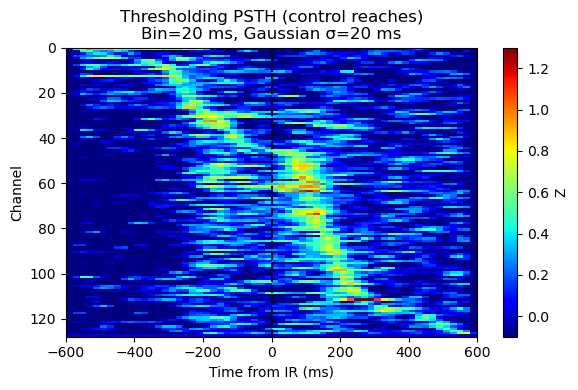

In [9]:
psth_plot_control, centers_from_edges = pad_bins_to_edges(psth_ch_sorted_control, centers_ms, edges_ms, tol=1e-3)

# plot
n_ch = psth_plot_control.shape[0]
y_edges = np.arange(n_ch + 1)

fig, ax = plt.subplots(figsize=(6,4))
ax.set_facecolor("0.5")
pc = ax.pcolormesh(
    edges_ms,
    y_edges,
    psth_plot_control,
    shading="flat",
    cmap="jet",
    vmin=-0.1,
    vmax=1.3,
)

ax.axvline(0, linestyle="--", color="black")
ax.set_ylim(n_ch, 0)
ax.set_xlabel("Time from IR (ms)")
ax.set_ylabel("Channel")
ax.set_title(f"Thresholding PSTH (control reaches)\nBin={BIN_MS} ms, Gaussian σ={SIGMA_MS} ms")
fig.colorbar(pc, ax=ax, label="Z")
plt.tight_layout()
plt.show()

## Stim trials show overdetecting spikes after stimulation

In [10]:
rec_nprw_stim = si.load(STIM_DATA)

In [11]:
IR_data_stim = '/home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/rates__NRR_RW026_260324_122125__bin20ms_sigma20ms.npz'

ir_si_obj_stim = np.load(IR_data_stim, allow_pickle=True) 
ir_ms = np.asarray(ir_si_obj_stim["ir_ms"], float).ravel()
ir_ms

array([ 8274.46666667, 13435.53333333, 17879.4       , 22649.43333333,
       28392.33333333, 33265.33333333, 38157.7       , 42717.46666667,
       47660.53333333, 54761.03333333, 60092.23333333])

In [12]:
noise_levels = si.get_noise_levels(rec_nprw_stim, method="mad", return_in_uV=False)
peaks = detect_peaks(
    rec_nprw_stim,
    method="by_channel_torch",
    method_kwargs=dict(detect_threshold=3, peak_sign="neg", noise_levels=noise_levels),
    job_kwargs=dict(n_jobs=1),
)
nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(peaks, 128)
nprw_peak_ms_stim = {k: v / 30000 * 1000.0 for k, v in nprw_peak_samps.items()}

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks (by_channel_torch) (no parallelization):   0%|          | 0/71 [00:00<?, ?it/s]

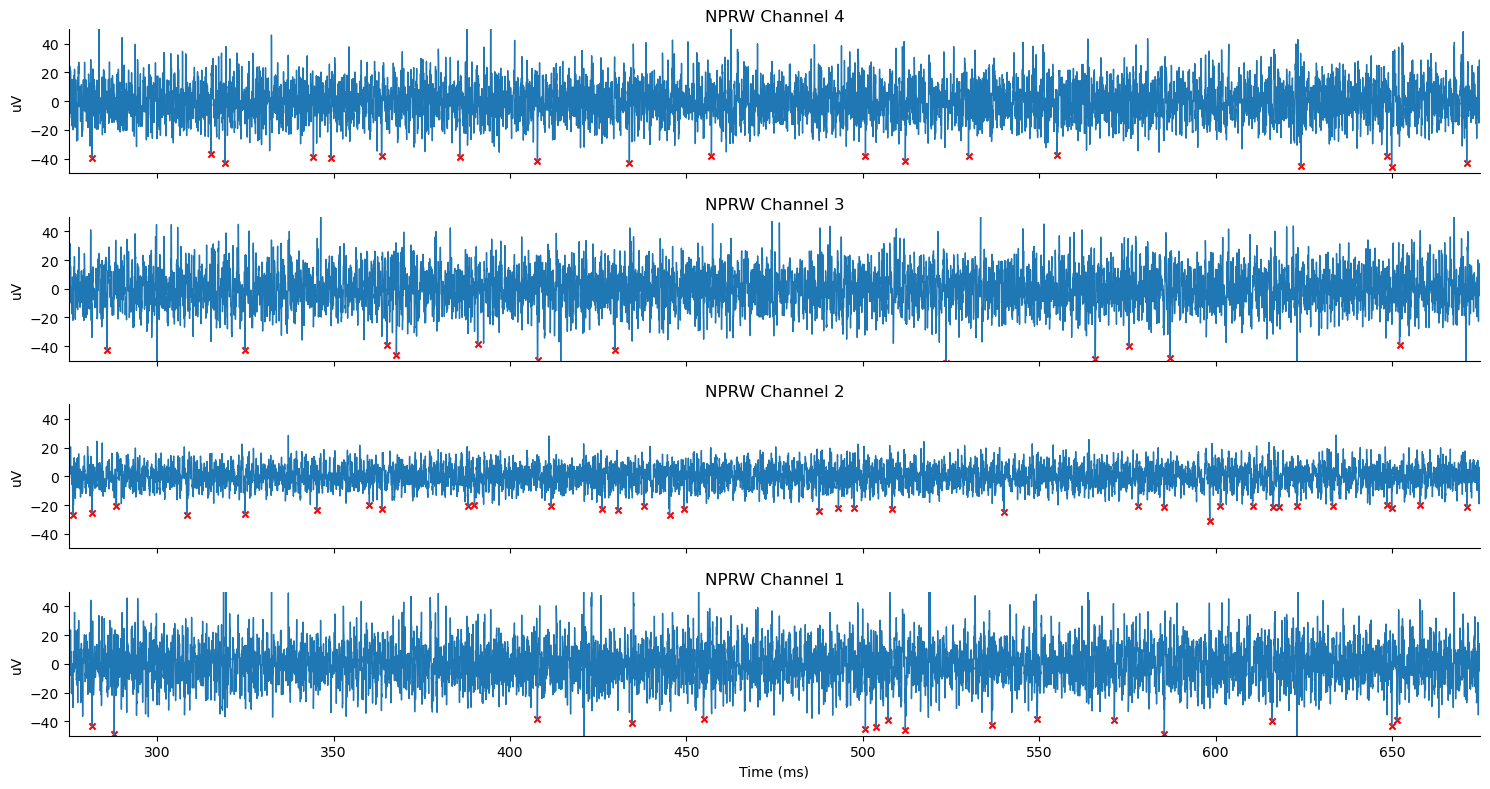

In [13]:
## Plotting raw trace with peaks
%matplotlib inline

CHANNELS  = [0, 1, 2, 3]
T0_MS     = 8247 / 30
T1_MS     = T0_MS + 400
PLOT_SHIFT = 30  # samples; compensates for threshold-crossing vs trough offset

fs = float(rec_nprw_stim.get_sampling_frequency())
i0 = int(T0_MS * fs / 1000.0)
i1 = int(T1_MS * fs / 1000.0)

fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(15, 3 * len(CHANNELS) / 1.5), sharex=True)
if len(CHANNELS) == 1:
    axes = [axes]

for ax, CH in zip(axes, CHANNELS[::-1]):
    ch_id = rec_nprw_stim.get_channel_ids()[CH]
    y = rec_nprw_stim.get_traces(start_frame=i0, end_frame=i1, channel_ids=[ch_id], return_in_uV=True).squeeze()
    t = np.arange(i0, i1) / fs * 1000.0

    pk_s = np.asarray(nprw_peak_samps.get(CH, nprw_peak_samps.get(np.int64(CH), [])), dtype=np.int64)
    m = (pk_s >= i0) & (pk_s < i1)
    pk_s_w = pk_s[m]
    pk_idx = (pk_s_w - i0).astype(int)
    pk_ms_w = pk_s_w / fs * 1000.0
    pk_y = y[pk_idx + PLOT_SHIFT]

    ax.plot(t, y, lw=1)
    if pk_ms_w.size:
        ax.scatter(pk_ms_w + PLOT_SHIFT / 30, pk_y, s=20, marker="x", color="red")
    ax.set_xlim(T0_MS, T1_MS)
    ax.set_ylim(-50, 50)
    ax.set_ylabel("uV")
    ax.set_title(f"NPRW Channel {CH + 1}")
    ax.spines[["right", "top"]].set_visible(False)

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

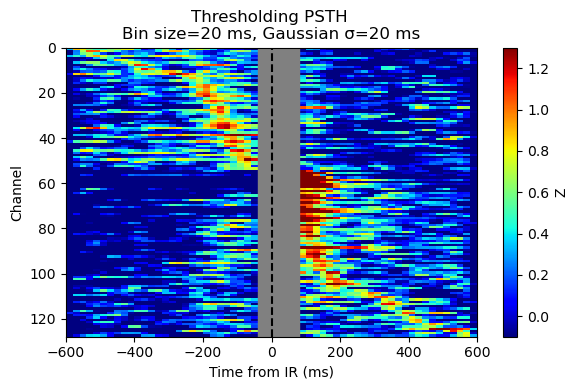

In [14]:
## PSTH shows artifact after stim
BIN_MS = 20
SIGMA_MS = 20

rates_hz_stim, centers_ms, unit_ids, edges_ms = peri_event_rates_from_peaks_ms( ## Extract peri-reach firing rates
    peaks_ms=nprw_peak_ms_stim,
    event_times_ms=ir_ms,
    win_ms=(-600, 600),
    bin_ms=BIN_MS,
    sigma_ms=SIGMA_MS,
)
# z score per channel
mu  = np.nanmean(rates_hz_stim[:, :, :], axis=2, keepdims=True)
sig = np.nanstd (rates_hz_stim[:, :, :], axis=2, keepdims=True)
sig = np.clip(sig, 1e-6, None)
rates_z = (rates_hz_stim - mu) / sig
psth_z = np.nanmean(rates_z, axis=0)

peak_mask = (centers_ms >= -600) & (centers_ms <= 600)

X = psth_z
t = centers_ms

# Peak value and peak time (argmax) within the search window
X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

# Keep only neurons with a real response; rest go to bottom
z_thresh = 0.1  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])

psth_ch_sorted_stim = psth_z[order]
psth_plot_stim, centers_from_edges = pad_bins_to_edges(psth_ch_sorted_stim, centers_ms, edges_ms, tol=1e-3)

# plot
n_ch = psth_plot_stim.shape[0]
y_edges = np.arange(n_ch + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_facecolor("0.5")
pc = ax.pcolormesh(
    edges_ms,
    y_edges,
    psth_plot_stim,
    shading="flat",
    cmap="jet",
    vmin=-0.1,
    vmax=1.3,
)
ax.axvspan(-40, 80, color="grey", alpha=1)
ax.axvline(0, linestyle="--", color="black")
ax.set_ylim(n_ch, 0)
ax.set_xlabel("Time from IR (ms)")
ax.set_ylabel("Channel")
ax.set_title(f"Thresholding PSTH \nBin size={BIN_MS} ms, Gaussian σ={SIGMA_MS} ms")
fig.colorbar(pc, ax=ax, label="Z")
plt.tight_layout()
plt.savefig("psth_stim_thresholding.svg", format="svg", bbox_inches="tight")
plt.show()

## Spike sorting control data to get waveform templates

In [15]:
import spikeinterface.curation as scur
import spikeinterface.sorters as ss
job_kwargs = dict(n_jobs=-1, progress_bar=True, chunk_duration="1s")
sorting_KS4 = ss.run_sorter(sorter_name="kilosort4", recording=rec_nprw_control, folder=NPRW_SORT_CKPT_OUT, remove_existing_folder=True)

sorting_KS4 = scur.remove_duplicated_spikes(sorting_KS4)
sorting_KS4 = scur.remove_excess_spikes(sorting_KS4, rec_nprw_control)
sorting_KS4 = scur.remove_redundant_units(sorting_KS4, align=False, remove_strategy="max_spikes")

analyzer = si.create_sorting_analyzer(sorting_KS4, rec_nprw_control,
                                              format="binary_folder", folder=NPRW_SORT_ANALYZE_CKPT_OUT,
                                              overwrite=True,
                                              **job_kwargs)
analyzer.compute(
    [
        "random_spikes",
        "waveforms",
        "templates",
        "noise_levels",
        "unit_locations",
        "isi_histograms",
        "correlograms",
        "principal_components",
        "quality_metrics",
        "template_similarity",
        "spike_amplitudes",
    ],
    extension_params={
        "quality_metrics": {
            "metric_names": ["snr", "firing_rate", "rp_violation"],
            "metric_params": {"rp_violation": {"refractory_period_ms": 0.5}},
        },
    },
    **job_kwargs
)
analyzer.get_saved_extension_names()

100%|██████████| 1/1 [00:02<00:00,  2.81s/it]


estimate_sparsity (workers: 12 processes fork):   0%|          | 0/134 [00:00<?, ?it/s]

/home/bryan/miniconda3/envs/pipeline/lib/python3.10/site-packages/spikeinterface/core/basesorting.py:384: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


compute_waveforms (workers: 12 processes fork):   0%|          | 0/134 [00:00<?, ?it/s]

noise_level (workers: 12 processes fork):   0%|          | 0/20 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/55 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/55 [00:00<?, ?it/s]

/home/bryan/miniconda3/envs/pipeline/lib/python3.10/site-packages/spikeinterface/postprocessing/template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


Compute : spike_amplitudes (workers: 12 processes fork):   0%|          | 0/134 [00:00<?, ?it/s]

['templates',
 'principal_components',
 'quality_metrics',
 'isi_histograms',
 'waveforms',
 'spike_amplitudes',
 'random_spikes',
 'unit_locations',
 'template_similarity',
 'correlograms',
 'noise_levels']

## Quality metric curation

In [16]:
qm = analyzer.get_extension("quality_metrics").get_data()
keep = (
    (qm["snr"] >= 3.0) &
    (qm["firing_rate"] >= 0.1) &
    (qm["rp_contamination"] <= 0.2)
)
print(f"Keeping {keep.sum()} / {len(keep)} units after QM curation")
analyzer = analyzer.select_units(unit_ids=analyzer.unit_ids[keep.values])

Keeping 7 / 55 units after QM curation


## Automerge oversplitting units to get units

In [17]:
from spikeinterface.curation import compute_merge_unit_groups

merge_unit_groups = compute_merge_unit_groups(
    sorting_analyzer=analyzer,
    preset="slay",
    resolve_graph=True
)
print(merge_unit_groups)
if merge_unit_groups is not None and len(merge_unit_groups) > 0:
    # here we apply the merges
    analyzer = analyzer.merge_units(merge_unit_groups=merge_unit_groups)

[]


## Waveform templates

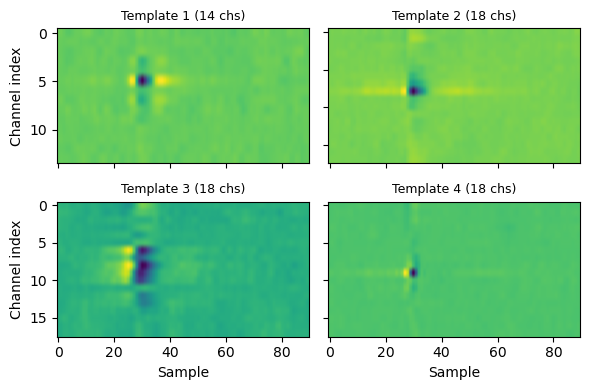

In [18]:
templates = analyzer.get_extension("templates")
avg = templates.data["average"]  # (n_units, n_samples, n_channels)

fig, axes = plt.subplots(2, 2, figsize=(6, 4))

for i, ax in enumerate(axes.flat):
    t = avg[i]
    active = np.where(t.std(axis=0) > 0)[0]
    ax.imshow(t[:, active].T, aspect="auto")
    ax.set_title(f"Template {i+1} ({len(active)} chs)", fontsize=9)

    row, col = divmod(i, 2)
    if row == 1:
        ax.set_xlabel("Sample")
    else:
        ax.set_xticklabels([])
    if col == 0:
        ax.set_ylabel("Channel index")
    else:
        ax.set_yticklabels([])

plt.savefig("templates.svg", format="svg", bbox_inches="tight")
plt.tight_layout()
plt.show()

## Get representative waveform for each neuron

In [19]:
extremum_channel_map = si.get_template_extremum_channel(analyzer)
unit_ids = analyzer.unit_ids

extremum_templates = []
for i, unit_id in enumerate(unit_ids):
    ch_id = extremum_channel_map[unit_id]
    ch_idx = rec_nprw_control.ids_to_indices(ids=[ch_id])[0]
    extremum_templates.append(templates.data['average'][i, :, ch_idx])

extremum_templates = np.stack(extremum_templates)  # shape: (46, 90)

## Plot canonical waveform determined from sorted neurons

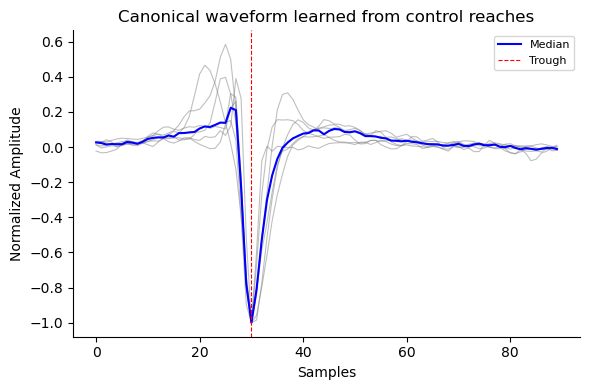

In [20]:
fs = rec_nprw_control.get_sampling_frequency()
extremum_templates_norm = extremum_templates / np.abs(extremum_templates).max(axis=1, keepdims=True)
median_extremum_templates_norm = np.median(extremum_templates_norm, axis=0)
nbefore = np.argmin(median_extremum_templates_norm)
nafter = len(median_extremum_templates_norm) - nbefore
ms_before = nbefore / fs * 1000
ms_after = nafter / fs * 1000

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(len(extremum_templates_norm)):
    ax.plot(extremum_templates_norm[i], color="grey", alpha=0.5, linewidth=0.8)
ax.plot(median_extremum_templates_norm, color="blue", linewidth=1.5, label="Median")
ax.axvline(nbefore, color="red", linestyle="--", linewidth=0.8, label="Trough")
ax.set_xlabel("Samples")
ax.set_ylabel("Normalized Amplitude")
ax.set_title("Canonical waveform learned from control reaches")
ax.legend(fontsize=8)
ax.spines[["right", "top"]].set_visible(False)
plt.savefig("canonical_waveform.svg", format="svg", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [21]:
THRESH = 4

In [22]:
from spikeinterface.sortingcomponents.peak_detection import detect_peaks
noise_levels = si.get_noise_levels(rec_nprw_stim, method="mad", return_in_uV=False) # They didn't write return_in_uV in their documentation

nprw_peaks_mf = detect_peaks(
    rec_nprw_stim,
    method="matched_filtering",
    method_kwargs=dict(
        detect_threshold=3,
        peak_sign='neg',
        ms_before=ms_before,
        prototype=median_extremum_templates_norm,
        radius_um=0,
    ),
    job_kwargs=dict(n_jobs=-1),
)

nprw_peak_samps_mf, nprw_peak_amps_mf = _parse_SI_peaks(nprw_peaks_mf, 128)
nprw_peak_ms_mf   = {k: (v / 30000)   * 1000.0 for k, v in nprw_peak_samps_mf.items()}


detect peaks (matched_filtering) (workers: 12 processes fork):   0%|          | 0/71 [00:00<?, ?it/s]

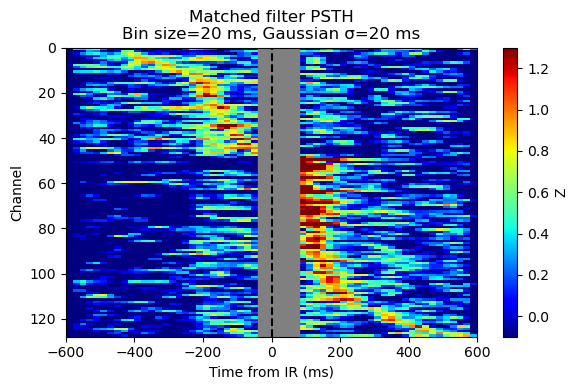

In [23]:
rates_hz, centers_ms, unit_ids, edges_ms = peri_event_rates_from_peaks_ms( ## Extract peri-reach firing rates
    peaks_ms=nprw_peak_ms_mf,
    event_times_ms=ir_ms,
    win_ms=(-600, 600),
    bin_ms=BIN_MS,
    sigma_ms=SIGMA_MS,
)
# z score per channel
mu  = np.nanmean(rates_hz[:, :, :], axis=2, keepdims=True)
sig = np.nanstd (rates_hz[:, :, :], axis=2, keepdims=True)
sig = np.clip(sig, 1e-6, None)
rates_z = (rates_hz - mu) / sig
psth_z = np.nanmean(rates_z, axis=0)

peak_mask = (centers_ms >= -600) & (centers_ms <= 600)

X = psth_z
t = centers_ms

# Peak value and peak time (argmax) within the search window
X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

# Keep only neurons with a real response; rest go to bottom
z_thresh = 0.1  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])

psth_ch_sorted = psth_z[order]
psth_plot, centers_from_edges = pad_bins_to_edges(psth_ch_sorted, centers_ms, edges_ms, tol=1e-3)

# plot
n_ch = psth_plot.shape[0]
y_edges = np.arange(n_ch + 1)

fig, ax = plt.subplots(figsize=(6,4))
ax.set_facecolor("0.5")
pc = ax.pcolormesh(
    edges_ms,
    y_edges,
    psth_plot,
    shading="flat",
    cmap="jet",
    vmin=-0.1,
    vmax=1.3,
)

ax.axvspan(-40, 80, color="grey", alpha=1)
ax.axvline(0, linestyle="--", color="black")
ax.set_ylim(n_ch, 0)
ax.set_xlabel("Time from IR (ms)")
ax.set_ylabel("Channel")
ax.set_title(f"Matched filter PSTH\nBin size={BIN_MS} ms, Gaussian σ={SIGMA_MS} ms")
fig.colorbar(pc, ax=ax, label="Z")
plt.tight_layout()
plt.savefig("psth_stim_mf.svg", format="svg", bbox_inches="tight")
plt.show()

In [24]:
centers_from_edges

array([-590., -570., -550., -530., -510., -490., -470., -450., -430.,
       -410., -390., -370., -350., -330., -310., -290., -270., -250.,
       -230., -210., -190., -170., -150., -130., -110.,  -90.,  -70.,
        -50.,  -30.,  -10.,   10.,   30.,   50.,   70.,   90.,  110.,
        130.,  150.,  170.,  190.,  210.,  230.,  250.,  270.,  290.,
        310.,  330.,  350.,  370.,  390.,  410.,  430.,  450.,  470.,
        490.,  510.,  530.,  550.,  570.,  590.])

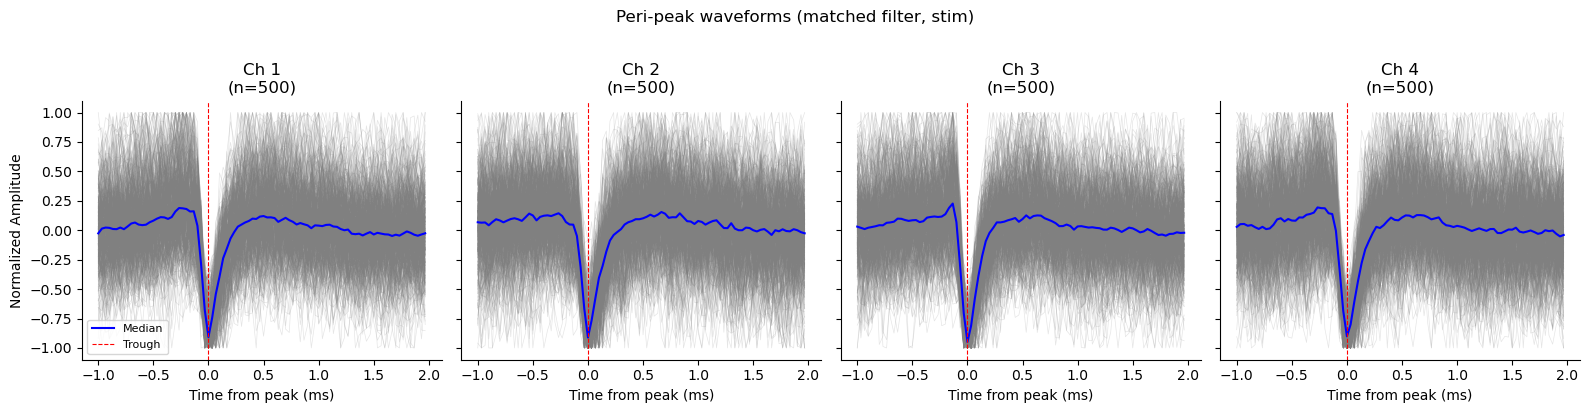

In [25]:
# Peri-peak waveforms from matched-filter detections on stim data
N_BEFORE = nbefore  # samples before trough (reuse from canonical waveform computation)
N_AFTER  = nafter   # samples after trough

CHANNELS_TO_PLOT = [0, 1, 2, 3]
MAX_WAVEFORMS = 500  # cap to avoid overplotting

fig, axes = plt.subplots(1, len(CHANNELS_TO_PLOT), figsize=(4 * len(CHANNELS_TO_PLOT), 4), sharey=True)

for ax, CH in zip(axes, CHANNELS_TO_PLOT):
    ch_id  = rec_nprw_stim.get_channel_ids()[CH]
    ch_idx = rec_nprw_stim.ids_to_indices(ids=[ch_id])[0]

    pk_s = np.asarray(nprw_peak_samps_mf.get(CH, nprw_peak_samps_mf.get(np.int64(CH), [])), dtype=np.int64)
    n_samps = rec_nprw_stim.get_num_samples()
    pk_s = pk_s[(pk_s >= N_BEFORE) & (pk_s < n_samps - N_AFTER)]

    rng = np.random.default_rng(0)
    if len(pk_s) > MAX_WAVEFORMS:
        pk_s = rng.choice(pk_s, MAX_WAVEFORMS, replace=False)
        pk_s.sort()

    waveforms = []
    for s in pk_s:
        snippet = rec_nprw_stim.get_traces(
            start_frame=int(s - N_BEFORE),
            end_frame=int(s + N_AFTER),
            channel_ids=[ch_id],
            return_in_uV=True,
        ).squeeze()  # (N_BEFORE + N_AFTER,)
        waveforms.append(snippet)

    if not waveforms:
        ax.set_title(f"Ch {CH+1}\n(no peaks)")
        continue

    waveforms = np.stack(waveforms)  # (n_peaks, n_samples)
    waveforms_norm = waveforms / np.abs(waveforms).max(axis=1, keepdims=True)
    median_wf = np.median(waveforms_norm, axis=0)

    t_ms = (np.arange(N_BEFORE + N_AFTER) - N_BEFORE) / fs * 1000.0

    for w in waveforms_norm:
        ax.plot(t_ms, w, color="grey", alpha=0.2, linewidth=0.5)
    ax.plot(t_ms, median_wf, color="blue", linewidth=1.5, label="Median")
    ax.axvline(0, color="red", linestyle="--", linewidth=0.8, label="Trough")
    ax.set_xlabel("Time from peak (ms)")
    ax.set_title(f"Ch {CH+1}\n(n={len(waveforms)})")
    ax.spines[["right", "top"]].set_visible(False)

axes[0].set_ylabel("Normalized Amplitude")
axes[0].legend(fontsize=8)
plt.suptitle("Peri-peak waveforms (matched filter, stim)", y=1.02)
plt.tight_layout()
plt.savefig("peri_peak_waveforms_mf.svg", format="svg", bbox_inches="tight")
plt.show()

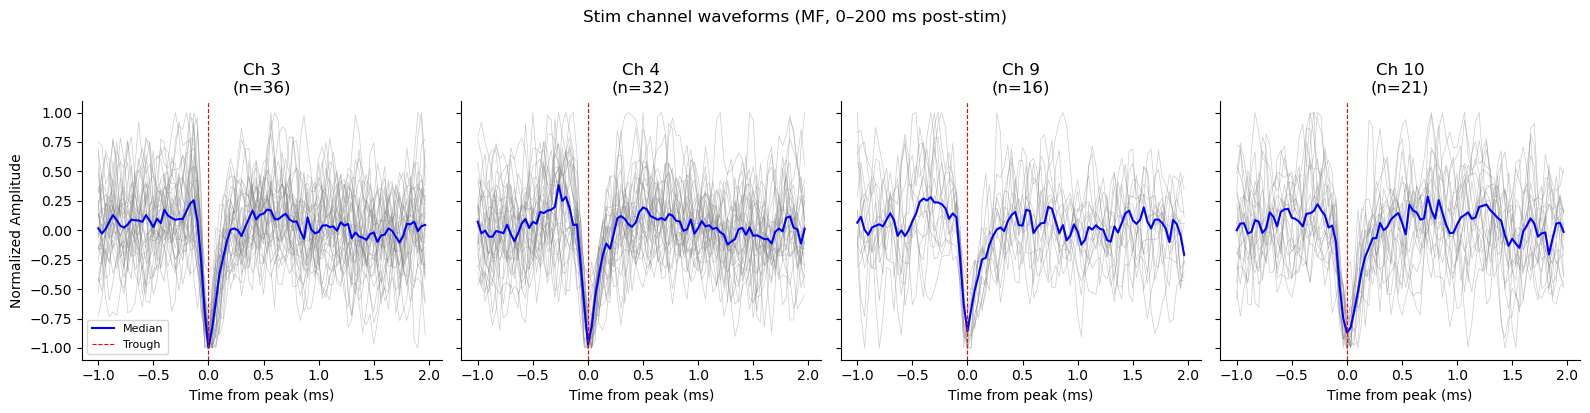

In [47]:
peri_npz_path = '/home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260324_NRR_RW026/results/checkpoints/PeriStim/stim_reaches/target_A/peristim__NRR_RW026_260324_122125__BR_002_target_A.npz'
peri_npz = np.load(peri_npz_path, allow_pickle=True)
nprw_meta = peri_npz["nprw_meta"].item()
stim_channels_0idx = nprw_meta["stim_channels"] - 1  # 0-indexed
stim_times_ms = peri_npz["event_ms"].ravel()          # stim pulse onsets

def peaks_within_post_stim_window(pk_s, stim_times_ms, win_ms, fs):
    pk_ms = pk_s / fs * 1000.0
    win_lo, win_hi = win_ms
    rel = pk_ms[:, None] - stim_times_ms[None, :]  # vectorized: (n_peaks, n_stims)
    keep = np.any((rel >= win_lo) & (rel <= win_hi), axis=1)
    return pk_s[keep]

CHANNELS_TO_PLOT = stim_channels_0idx[:4].tolist()
POST_STIM_WIN_MS = (0, 200)
MAX_WAVEFORMS = 500

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, CH in zip(axes, CHANNELS_TO_PLOT):
    ch_id = rec_nprw_stim.get_channel_ids()[CH]

    pk_s = np.asarray(nprw_peak_samps_mf.get(CH, nprw_peak_samps_mf.get(np.int64(CH), [])), dtype=np.int64)
    n_samps = rec_nprw_stim.get_num_samples()
    pk_s = pk_s[(pk_s >= N_BEFORE) & (pk_s < n_samps - N_AFTER)]
    pk_s = peaks_within_post_stim_window(pk_s, stim_times_ms, POST_STIM_WIN_MS, fs)

    rng = np.random.default_rng(0)
    if len(pk_s) > MAX_WAVEFORMS:
        pk_s = rng.choice(pk_s, MAX_WAVEFORMS, replace=False)
        pk_s.sort()

    waveforms = []
    for s in pk_s:
        snippet = rec_nprw_stim.get_traces(
            start_frame=int(s - N_BEFORE),
            end_frame=int(s + N_AFTER),
            channel_ids=[ch_id],
            return_in_uV=True,
        ).squeeze()
        waveforms.append(snippet)

    if not waveforms:
        ax.set_title(f"Ch {CH+1}\n(no peaks)")
        ax.spines[["right", "top"]].set_visible(False)
        continue

    waveforms = np.stack(waveforms)
    waveforms_norm = waveforms / np.abs(waveforms).max(axis=1, keepdims=True)
    median_wf = np.median(waveforms_norm, axis=0)
    t_ms = (np.arange(N_BEFORE + N_AFTER) - N_BEFORE) / fs * 1000.0

    for w in waveforms_norm:
        ax.plot(t_ms, w, color="grey", alpha=0.4, linewidth=0.5)
    ax.plot(t_ms, median_wf, color="blue", linewidth=1.5, label="Median")
    ax.axvline(0, color="red", linestyle="--", linewidth=0.8, label="Trough")
    ax.set_xlabel("Time from peak (ms)")
    ax.set_title(f"Ch {CH+1}\n(n={len(waveforms)})")
    ax.spines[["right", "top"]].set_visible(False)

axes[0].set_ylabel("Normalized Amplitude")
axes[0].legend(fontsize=8)
plt.suptitle(f"Stim channel waveforms (MF, {POST_STIM_WIN_MS[0]}–{POST_STIM_WIN_MS[1]} ms post-stim)", y=1.02)
plt.tight_layout()
plt.savefig("peri_peak_waveforms_stim_channels.svg", format="svg", bbox_inches="tight")
plt.show()

In [46]:
print("stim_channels (raw):", nprw_meta["stim_channels"])
print("max channel index in SI:", len(rec_nprw_stim.get_channel_ids()) - 1)  # should be 127

stim_channels (raw): [  3   4   9  10  11  12  13  14  19  20  39  40  51  52  61  62  71  72
  93  94 119 120 127 128]
max channel index in SI: 127
